In [1]:
!pip install datasets imbalanced-learn emoji scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 28.0 MB/s eta 0:00:00


In [5]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

from imblearn.over_sampling import RandomOverSampler

In [18]:
dataset = load_dataset("tweet_eval", "sentiment")

texts = dataset['train']['text']
labels = dataset['train']['label']

/tmp/ipykernel_9470/3183150635.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="sentiment", data=train_df,


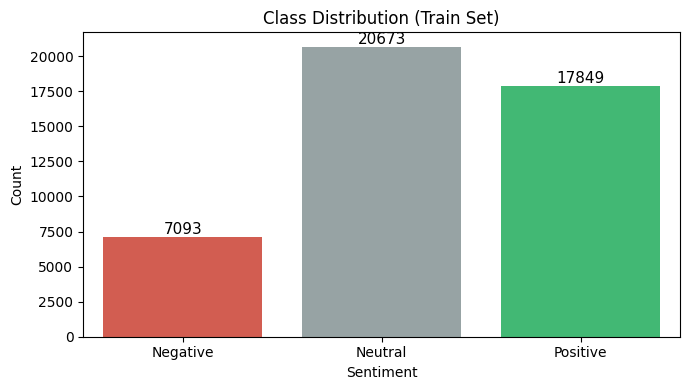

In [27]:
# ── EDA Cell 1: Class Distribution ──────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}

train_df = pd.DataFrame({
    "text": dataset['train']['text'],
    "label": dataset['train']['label']
})
train_df["sentiment"] = train_df["label"].map(label_names)

plt.figure(figsize=(7, 4))
ax = sns.countplot(x="sentiment", data=train_df,
                   order=["Negative", "Neutral", "Positive"],
                   palette=["#e74c3c", "#95a5a6", "#2ecc71"])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title("Class Distribution (Train Set)")
plt.xlabel("Sentiment"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig("class_distribution.png", dpi=150); plt.show()

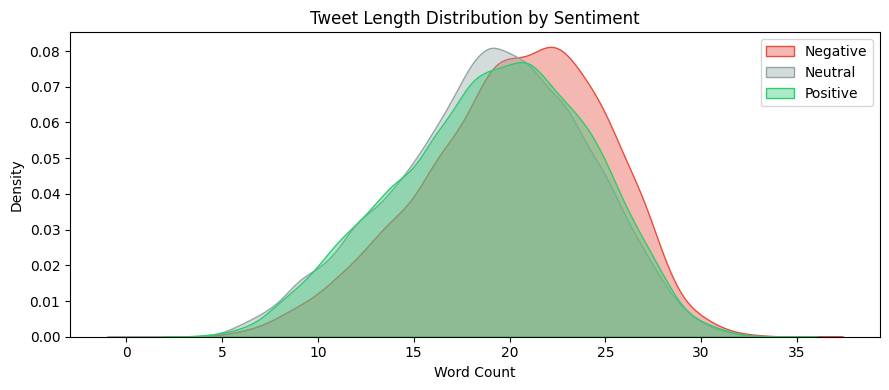

             count   mean   std  min   25%   50%   75%   max
sentiment                                                   
Negative    7093.0  20.22  4.76  4.0  17.0  21.0  24.0  35.0
Neutral    20673.0  18.98  4.92  1.0  16.0  19.0  23.0  33.0
Positive   17849.0  19.15  4.97  4.0  16.0  19.0  23.0  34.0


In [28]:
# ── EDA Cell 2: Tweet Length Distribution ────────────────────────────────
train_df["text_length"] = train_df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(9, 4))
for label, color in zip(["Negative", "Neutral", "Positive"],
                         ["#e74c3c", "#95a5a6", "#2ecc71"]):
    subset = train_df[train_df["sentiment"] == label]["text_length"]
    sns.kdeplot(subset, label=label, fill=True, alpha=0.4, color=color)

plt.title("Tweet Length Distribution by Sentiment")
plt.xlabel("Word Count"); plt.ylabel("Density")
plt.legend(); plt.tight_layout()
plt.savefig("length_distribution.png", dpi=150); plt.show()

print(train_df.groupby("sentiment")["text_length"].describe().round(2))

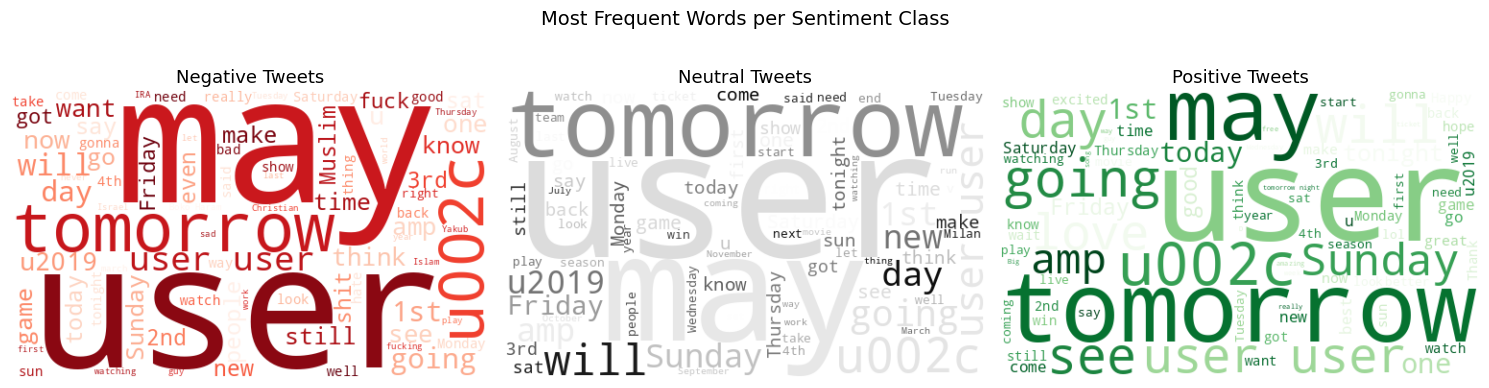

In [30]:
# ── EDA Cell 3: Top Words per Class (WordCloud) ───────────────────────────
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles  = ["Negative", "Neutral", "Positive"]
colors  = ["Reds", "Greys", "Greens"]

for ax, sentiment, cmap in zip(axes, titles, colors):
    text_blob = " ".join(train_df[train_df["sentiment"] == sentiment]["text"].tolist())
    wc = WordCloud(width=500, height=300, background_color="white",
                   colormap=cmap, max_words=80).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{sentiment} Tweets", fontsize=13)
    ax.axis("off")

plt.suptitle("Most Frequent Words per Sentiment Class", fontsize=14, y=1.02)
plt.tight_layout(); plt.savefig("wordclouds.png", dpi=150); plt.show()

In [29]:
# ── EDA Cell 4: Sample Tweets per Class ──────────────────────────────────
print("=== Sample Tweets per Class ===\n")
for sentiment in ["Negative", "Neutral", "Positive"]:
    print(f"--- {sentiment} ---")
    samples = train_df[train_df["sentiment"] == sentiment]["text"].sample(3, random_state=42).tolist()
    for s in samples:
        print(f"  • {s}")
    print()

=== Sample Tweets per Class ===

--- Negative ---
  • "#CNET - Just bought my 1st iPad, iPad3, feeling real burned, mad, about iPad4 so soon. Grrr. REALLY mad! Don't even care about mini now,"
  • "Mother's Day is coming like tomorrow or is it today? idk, but i didn't prepare anything for me's mom."
  • Can't believe I left my charger at Tia's. I have just under 50% until tomorrow, so in living on my IPod. You can only contact me via Twitter

--- Neutral ---
  • @user @user @user  I think this is the motive of the Yakub's laywers for pursuing the case
  • @user From this performance it is obvious why David Miliband comes up 1st when you google Miliband! #onetowatch
  • @user @user We are actually playing on Saturday\u002c January 19 - the week prior to the Senior Bowl.

--- Positive ---
  • Kanye West was honored in a big way during Sunday night's MTV Video Music Awards by receiving the Michael Jackso...
  • Have you heard about Amazon Prime day? Don't miss it - July 15th! Yay! #ad #Pr

In [19]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = emoji.demojize(text)
    return text

texts = [preprocess(t) for t in texts]

In [20]:
vectorizer = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True
)

X = vectorizer.fit_transform(texts)
y = np.array(labels)

In [21]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res
)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB()
}

In [25]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


Logistic Regression
Accuracy: 0.7350854563044179
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      4135
           1       0.66      0.64      0.65      4134
           2       0.75      0.70      0.72      4135

    accuracy                           0.74     12404
   macro avg       0.73      0.74      0.73     12404
weighted avg       0.73      0.74      0.73     12404


SVM
Accuracy: 0.7658819735569171
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      4135
           1       0.71      0.63      0.67      4134
           2       0.75      0.73      0.74      4135

    accuracy                           0.77     12404
   macro avg       0.76      0.77      0.76     12404
weighted avg       0.76      0.77      0.76     12404


Naive Bayes
Accuracy: 0.6916317316994518
              precision    recall  f1-score   support

           0       0.71      0.88      0.78      4135
   

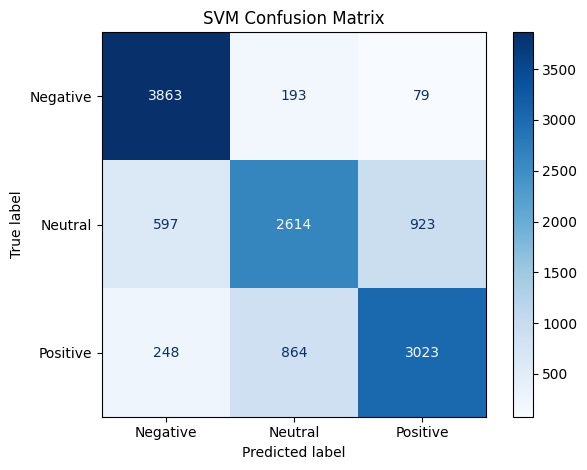

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions from the best model
best_model = models["SVM"]
y_pred = best_model.predict(X_test)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"])

disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.savefig("svm_confusion_matrix.png", dpi=150)
plt.show()

Error Analysis Section

In [31]:
# ── Error Analysis Cell 1: Misclassified Examples ────────────────────────
best_model = models["SVM"]
y_pred = best_model.predict(X_test)

# Rebuild test texts for error analysis (run this before vectorizer.transform)
# Note: X_test indices map to texts_test — reconstruct using a master list
label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}

errors_df = pd.DataFrame({
    "true_label":      [label_names[l] for l in y_test],
    "predicted_label": [label_names[l] for l in y_pred],
})
errors_df["correct"] = errors_df["true_label"] == errors_df["predicted_label"]

print("=== Misclassification Summary ===")
misclf = errors_df[~errors_df["correct"]]
pivot = misclf.groupby(["true_label", "predicted_label"]).size().reset_index(name="count")
print(pivot.sort_values("count", ascending=False).to_string(index=False))

=== Misclassification Summary ===
true_label predicted_label  count
   Neutral        Positive    923
  Positive         Neutral    864
   Neutral        Negative    597
  Positive        Negative    248
  Negative         Neutral    193
  Negative        Positive     79


/tmp/ipykernel_9470/1256953570.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="true_label", y="error_rate_%", data=error_rates,


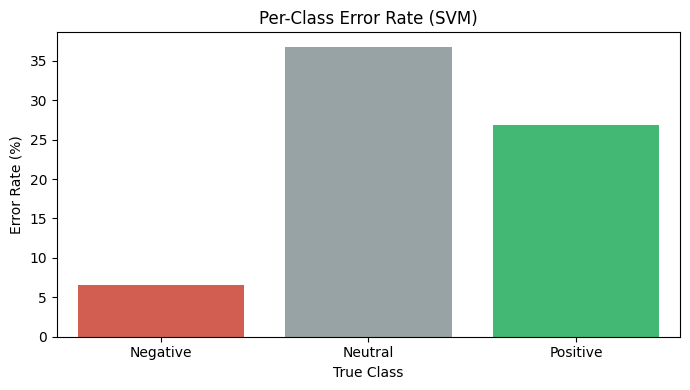

In [32]:
# ── Error Analysis Cell 2: Per-Class Error Rate ───────────────────────────
plt.figure(figsize=(7, 4))
error_rates = (
    errors_df.groupby("true_label")["correct"]
    .apply(lambda x: (~x).sum() / len(x) * 100)
    .reset_index(name="error_rate_%")
)
sns.barplot(x="true_label", y="error_rate_%", data=error_rates,
            palette=["#e74c3c", "#95a5a6", "#2ecc71"],
            order=["Negative", "Neutral", "Positive"])
plt.title("Per-Class Error Rate (SVM)")
plt.ylabel("Error Rate (%)"); plt.xlabel("True Class")
plt.tight_layout(); plt.savefig("error_rates.png", dpi=150); plt.show()

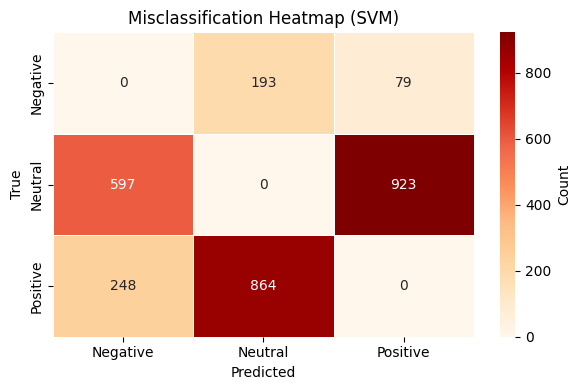

In [35]:
# ── Error Analysis Cell 3: Misclassification Heatmap ─────────────────────
plt.figure(figsize=(6, 4))
pivot_heatmap = misclf.groupby(["true_label", "predicted_label"]).size().unstack(fill_value=0)
sns.heatmap(pivot_heatmap, annot=True, fmt="d", cmap="OrRd",
            linewidths=0.5, cbar_kws={"label": "Count"})
plt.title("Misclassification Heatmap (SVM)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.savefig("misclassification_heatmap.png", dpi=150); plt.show()

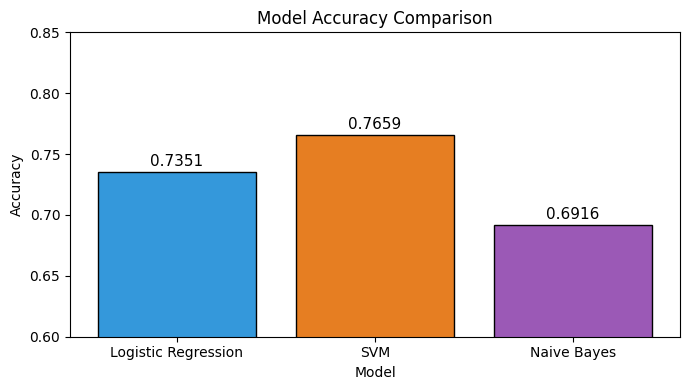

In [33]:
# ── Error Analysis Cell 4: Model Comparison Bar Chart ─────────────────────
results = {
    "Logistic Regression": 0.7351,
    "SVM":                 0.7659,
    "Naive Bayes":         0.6916,
}

plt.figure(figsize=(7, 4))
bars = plt.bar(results.keys(), results.values(),
               color=["#3498db", "#e67e22", "#9b59b6"], edgecolor="black")
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", fontsize=11)
plt.ylim(0.6, 0.85)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy"); plt.xlabel("Model")
plt.tight_layout(); plt.savefig("model_comparison.png", dpi=150); plt.show()

In [34]:
# ── Save Best Model ────────────────────────────────────────────────────────
import joblib

best_model = models["SVM"]          # best performing model
joblib.dump(best_model, "best_model_svm.pkl")
joblib.dump(vectorizer,  "tfidf_vectorizer.pkl")

print("✅ Model and vectorizer saved successfully!")
print("   → best_model_svm.pkl")
print("   → tfidf_vectorizer.pkl")

✅ Model and vectorizer saved successfully!
   → best_model_svm.pkl
   → tfidf_vectorizer.pkl
